# [LAB-10] 6. [PBT] Apple Quality

## #01. 준비작업

### 1. 라이브러리 참조

In [68]:
from jussam import load_data
from helpers import *
from IPython.display import display, Markdown

from pandas import DataFrame

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 불러오기

In [2]:
origin = load_data("apple_quality")
origin.head()

📚 이 데이터 세트는 다양한 과일 속성에 대한 정보를 담고 있어 과일의 특성을 파악하는 데 도움이 됩니다. 데이터 세트에는 과일 ID, 크기, 무게, 당도, 아삭함, 과즙량, 숙성도, 산도 및 품질과 같은 세부 정보가 포함되어 있습니다. (출처: https://www.kaggle.com/datasets/nelgiriyewithana/apple-quality)



field        description
-----------  ----------------------------------
A_id         각 과일에 대한 고유 식별자
Size         크기
Weight       무게
Sweetness    단맛 정도
Crunchiness  과일의 아삭한 식감을 나타내는 질감
Juiciness    과일의 과즙 함량 정도
Ripeness     과일이 익은 정도
Acidity      과일의 산도 수준
Quality      과일의 전반적인 품질



,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0,-3.970,-2.512,5.346,-1.012,1.845,0.330,-0.492,good
1,1,-1.195,-2.839,3.664,1.588,0.853,0.868,-0.723,good
2,2,-0.292,-1.351,-1.738,-0.343,2.839,-0.038,2.622,bad
3,3,-0.657,-2.272,1.325,-0.098,3.638,-3.414,0.791,good
4,4,1.364,-1.297,-0.385,-0.553,3.031,-1.304,0.502,good


### 3. 컬럼 의미를 정리한 딕셔너리

In [3]:
column_means = {
    "A_id":         "사과 식별자",
    "Size":         "크기",
    "Weight":       "무게",
    "Sweetness":    "단맛 정도",
    "Crunchiness":  "아삭한 식감",
    "Juiciness":    "과즙 함량",
    "Ripeness":     "익은 정도",
    "Acidity":      "산도",
    "Quality":      "품질 (good / bad)",
}

## #02. 데이터 품질 점검

### 1. 자료형 확인

In [4]:
origin.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   int64  
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4000 non-null   float64
 8   Quality      4000 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 281.4+ KB


### 2. 자료형 변환

- `A_id`는 **행마다 값이 모두 다른 식별자**이므로 분석 대상이 아니다. 여기서 제거한다.
  - 숫자로 저장되어 있어 그대로 두면 연속형 독립변수로 잘못 투입된다.
- 종속변수 `Quality`는 문자열이므로 **명목형(category)** 으로 변환한다.

In [62]:
df0 = origin.drop(columns=["A_id"])
df1 = my_qtcheck.set_type(df0, as_category=["Quality"])

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   Size         4000 non-null   float64 
 1   Weight       4000 non-null   float64 
 2   Sweetness    4000 non-null   float64 
 3   Crunchiness  4000 non-null   float64 
 4   Juiciness    4000 non-null   float64 
 5   Ripeness     4000 non-null   float64 
 6   Acidity      4000 non-null   float64 
 7   Quality      4000 non-null   category
dtypes: category(1), float64(7)
memory usage: 222.8 KB


### 3. 데이터 중복 점검

In [6]:
df2 = my_qtcheck.check_duplicates(df1)
df2.head()

중복된 행의 수: 0


,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,-3.970,-2.512,5.346,-1.012,1.845,0.330,-0.492,good
1,-1.195,-2.839,3.664,1.588,0.853,0.868,-0.723,good
2,-0.292,-1.351,-1.738,-0.343,2.839,-0.038,2.622,bad
3,-0.657,-2.272,1.325,-0.098,3.638,-3.414,0.791,good
4,1.364,-1.297,-0.385,-0.553,3.031,-1.304,0.502,good


### 4. 결측치 점검

In [7]:
my_qtcheck.check_missing_values(df2)

,Missing Count,Missing Ratio (%)
Size,0,0.000
Weight,0,0.000
Sweetness,0,0.000
Crunchiness,0,0.000
Juiciness,0,0.000
Ripeness,0,0.000
Acidity,0,0.000
Quality,0,0.000


> 중복도 결측치도 없다. 캐글 데이터셋 중에서는 드물게 **정제가 이미 끝난 상태**다.

### 5. 명목형 변수의 기술 통계량

In [8]:
cat_desc = my_qtcheck.categorical_summary(df2)
cat_desc

📊 컬럼 'Quality'의 value_counts():


,count
Quality,
bad,1996
good,2004


,Quality
count,4000
unique,2
top,good
freq,2004


### 6. 연속형 변수의 기술 통계량

In [64]:
num_desc = my_qtcheck.numerical_summary(df2)
num_desc.T

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
count,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000,4000.000
mean,-0.503,-0.990,-0.470,0.985,0.512,0.498,0.077
std,1.928,1.603,1.943,1.403,1.930,1.874,2.110
min,-7.152,-7.150,-6.894,-6.055,-5.962,-5.865,-7.011
25%,-1.817,-2.012,-1.738,0.063,-0.801,-0.772,-1.377
50%,-0.514,-0.985,-0.505,0.998,0.534,0.503,0.023
75%,0.806,0.031,0.802,1.894,1.836,1.766,1.510
max,6.406,5.791,6.375,7.620,7.364,7.238,7.405
rel_diff,-0.021,-0.005,-0.068,0.013,0.041,0.010,2.400
rdiff_flag,similar,similar,similar,similar,similar,similar,large_diff


#### 💡 인사이트 — 품질 점검 결과

| 점검 항목 | 결과 |
|---|---|
| 관측치 수 | 4,000건 (중복 0건, 결측 0건) |
| 식별자 | `A_id` 제거 |
| 종속변수 | `Quality` — `good` 2,004건 / `bad` 1,996건 |
| 연속형 독립변수 | 7종 (`Size` ~ `Acidity`) |
| 왜도 | 7종 **모두 `symmetric`** (\|왜도\| < 0.15) → 로그변환 대상 없음 |
| 이상치 | 7종 모두 **1.3% 이하** → 대체 여부는 뒤에서 체크포인트로 비교 |

- 값의 범위가 대략 −7 ~ +7이고 평균이 0 부근이다. **원 단위가 아니라 이미 표준화된 지표**로 제공된 데이터다.
  - 따라서 "크기 1 증가"는 mm나 g가 아니라 **표준화 점수 1점 증가**로 읽어야 한다.
- 종속변수가 **2,004 : 1,996으로 거의 완벽하게 균형**이다.
  - 정확도(Accuracy)의 함정(불균형 데이터에서 게으른 모형이 높은 점수를 받는 문제)이 **이 데이터에서는 발생하지 않는다.**

## #03. 변수 유형 분류와 EDA 범위

### 1. 변수 유형 분류

- 선형회귀 때와 **코드는 그대로**이고, `target_is_continuous`만 `False`로 바꾼다.

In [ ]:
target = "Quality"    # 종속변수
target_is_continuous = False    # 종속변수 연속형 여부  --> 로지스틱이므로 False
nominal_cols = my_qtcheck.get_categorical_column_names(df2) # 명목형 변수
continuous_cols = my_qtcheck.get_number_column_names(df2)   # 연속형 변수

if target_is_continuous:
    continuous_cols.remove(target)  # 연속형 변수 이름에서 종속변수 항목 제거
else:
    nominal_cols.remove(target)     # 명목형 변수 이름에서 종속변수 항목 제거

print("종속변수 :", target)
print("종속변수 유형: " + ("연속형" if target_is_continuous else "명목형"))
print("명목형   :", nominal_cols)
print("연속형   :", continuous_cols)

종속변수 : Quality
종속변수 유형: 명목형
명목형   : []
연속형   : ['Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness', 'Ripeness', 'Acidity']


### 2. 서열척도 적용 (필요에 따라 수행)

- 명목형 범주에 순서가 있다면 순서를 지정한다. (도메인 지식이 필요한 부분)
- 이 데이터셋에는 **서열척도 대상이 없다.** 코드는 다른 데이터셋에 그대로 옮겨 쓸 수 있도록 남겨 둔다.

In [ ]:
# 서열척도를 적용할 변수와 순서를 정의한다. (낮은 등급 → 높은 등급)
# -> 도메인 지식이 필요한 부분이다.
# -> 서열척도 대상이 없는 데이터셋이라면 빈 딕셔너리로 둔다.
ordinal_map = {}

# 정의된 내용에 따라 순서를 재지정한다.
# -> 데이터셋에 없는 컬럼은 건너뛰므로 다른 데이터셋에서도 오류가 나지 않는다.
df = df2.copy()

for col, order in ordinal_map.items():
    if col in df.columns:
        print(f"'{col}' 컬럼 순서 재지정 : {order}")
        df[col] = df[col].cat.reorder_categories(order, ordered=True)

### 3. EDA 범위 정리

| 종속유형 | 독립유형 | 분석 유형 | 대상 변수 | 적용 여부 | 비고 |
|---|---|---|---|---|---|
| 연속형 | 연속형 | 상관분석 | — | ❌ 미적용 | 종속변수 타입이 명목형 |
| 연속형 | 명목형(2집단) | T검정 | — | ❌ 미적용 | 종속변수 타입이 명목형 |
| 연속형 | 명목형(3집단+) | ANOVA | — | ❌ 미적용 | 종속변수 타입이 명목형 |
| **명목형(2집단)** | **연속형** | **T검정** | 연속형 독립변수 7종 → `Quality` | ✅ **적용** | 이 데이터의 핵심 |
| 명목형(2집단) | 명목형(2집단) | 교차분석 | — | ❌ 미적용 | 명목형 독립변수 없음 |
| 명목형(2집단) | 명목형(3집단+) | 교차분석 | — | ❌ 미적용 | 명목형 독립변수 없음 |
| 명목형(3집단+) | 연속형 | ANOVA | — | ❌ 미적용 | 종속변수가 2집단 |
| 명목형(3집단+) | 명목형(2집단) | 교차분석 | — | ❌ 미적용 | 종속변수가 2집단 |
| 명목형(3집단+) | 명목형(3집단+) | 교차분석 | — | ❌ 미적용 | 종속변수가 2집단 |

- 종속변수 `Quality`가 **명목형 2집단**이므로 4~6행만 후보가 되고, 그 중 독립변수가 실제로 존재하는 **T검정**만 수행된다.
- **주의** — 종속변수가 명목형이면 **상관분석(피어슨·스피어만)을 쓸 수 없다.**
  상관계수는 두 변수가 모두 연속형일 때 정의되는 지표이기 때문이다.
  같은 질문("이 변수가 품질과 관련이 있는가")에 답하는 도구가 **T검정**으로 바뀐다.

## #04. 단변량 분석

### 1. 명목형 종속변수에 대한 단변량 분석

- 선형회귀에서는 종속변수의 **분포 모양(왜도·이상치)** 을 봤지만,
  로지스틱 회귀에서는 종속변수의 **범주 비율(균형 여부)** 을 본다.

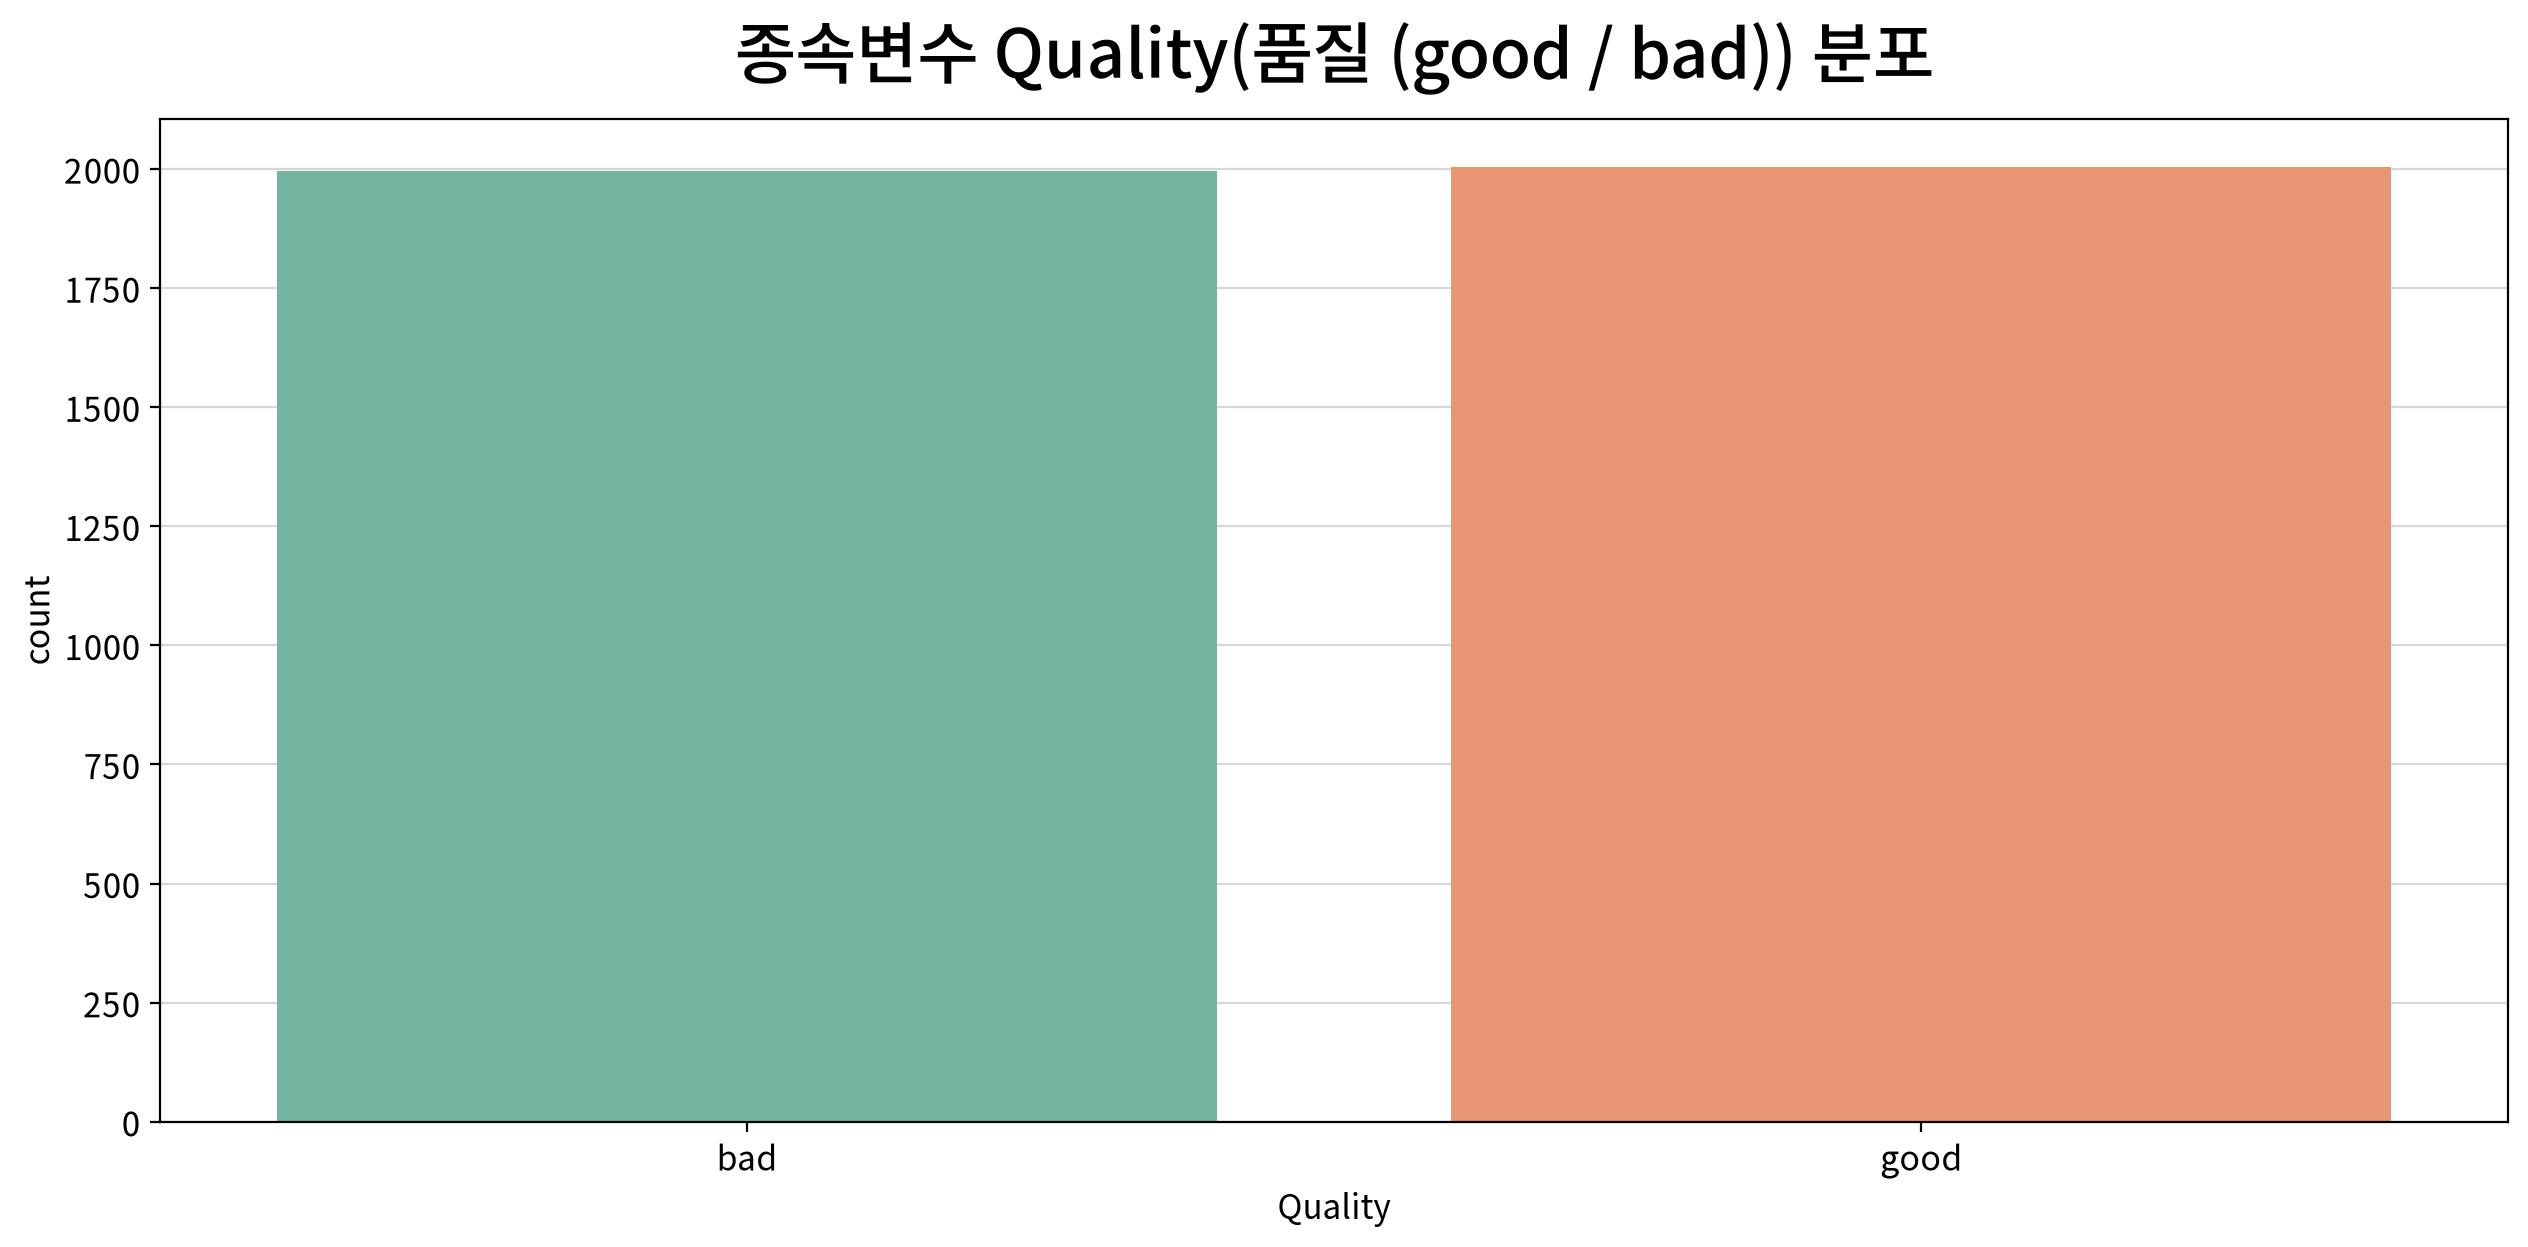

,count,unique,top,freq
Quality,4000,2,good,2004


,빈도,비율
Quality,,
good,2004,0.501
bad,1996,0.499


In [12]:
# 명목형 분포는 카운트 플롯으로 처리한다.
my_plot.countplot(data=df, x=target, hue=target, palette="Set2",
                  title=f"종속변수 {target}({column_means[target]}) 분포")

# 명목형 기술통계량
display(cat_desc[[target]].T)

# 추가적으로 빈도표 생성
freq = df[target].value_counts().rename("빈도").to_frame()
# value_counts(normalize=True)
# --> 전체 고유값의 개수(빈도수) 대신 전체 데이터의 비율을 계산
freq["비율"] = df[target].value_counts(normalize=True)
display(freq)

#### 💡 인사이트

| 점검 항목 | `Quality` 관찰값 |
|---|---|
| 범주 수 | 2 (`good` / `bad`) → **이분형** 이므로 로지스틱 회귀 적용 가능 |
| 최빈 범주 | `good` 2,004건 (50.1%) |
| 최소 범주 | `bad` 1,996건 (49.9%) |
| 균형 여부 | **거의 완벽한 균형** (차이 8건, 0.2%p) |

- 균형 데이터이므로 **정확도(Accuracy)를 그대로 신뢰해도 되는 드문 경우**다.
  - 무조건 `good`이라고만 답하는 게으른 모형의 정확도는 **50.1%** 에 그친다.
  - 즉 정확도 50%가 이 데이터의 **바닥값(baseline)** 이고, 모형은 그보다 얼마나 올라가는지로 평가한다.

### 2. 연속형 독립변수에 대한 단변량 분석

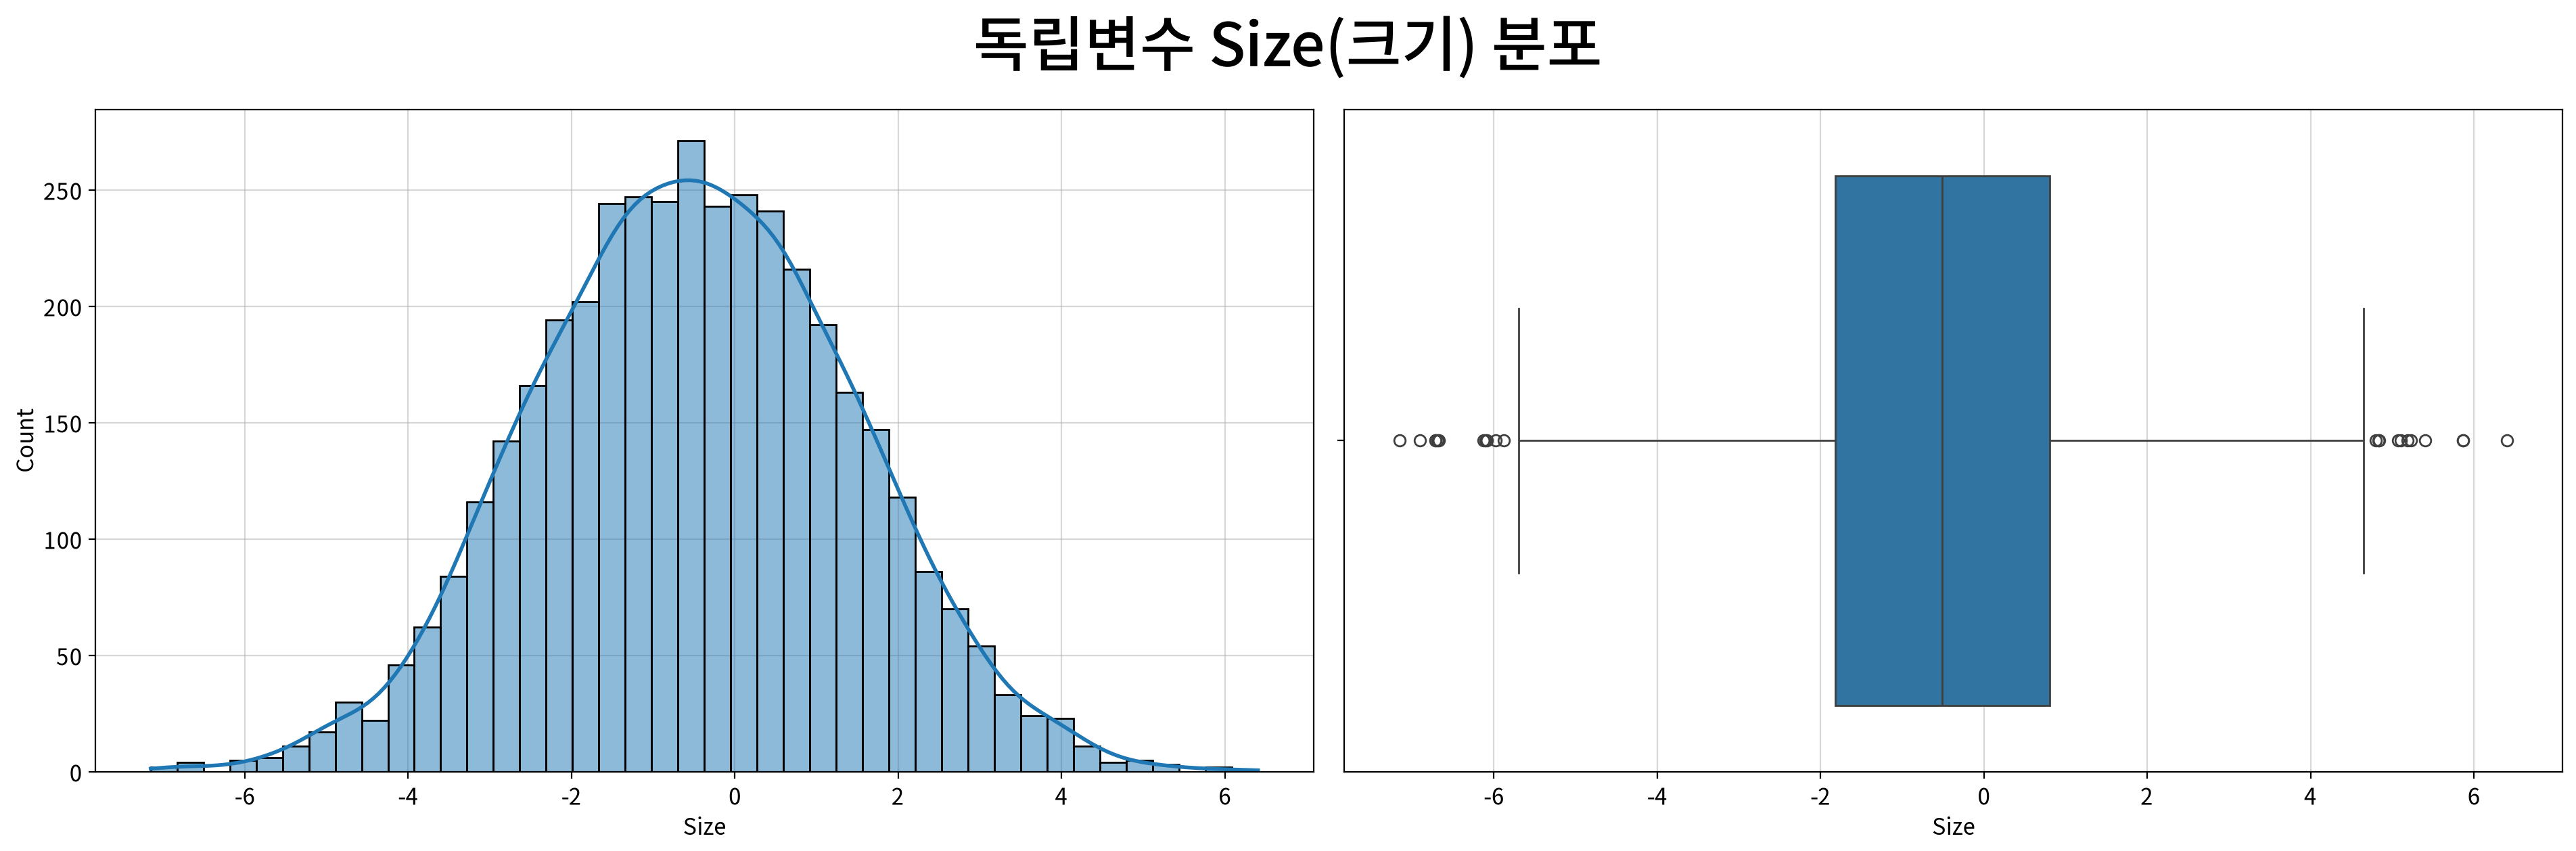

,Size
count,4000.000
mean,-0.503
std,1.928
min,-7.152
25%,-1.817
50%,-0.514
75%,0.806
max,6.406
rel_diff,-0.021
rdiff_flag,similar


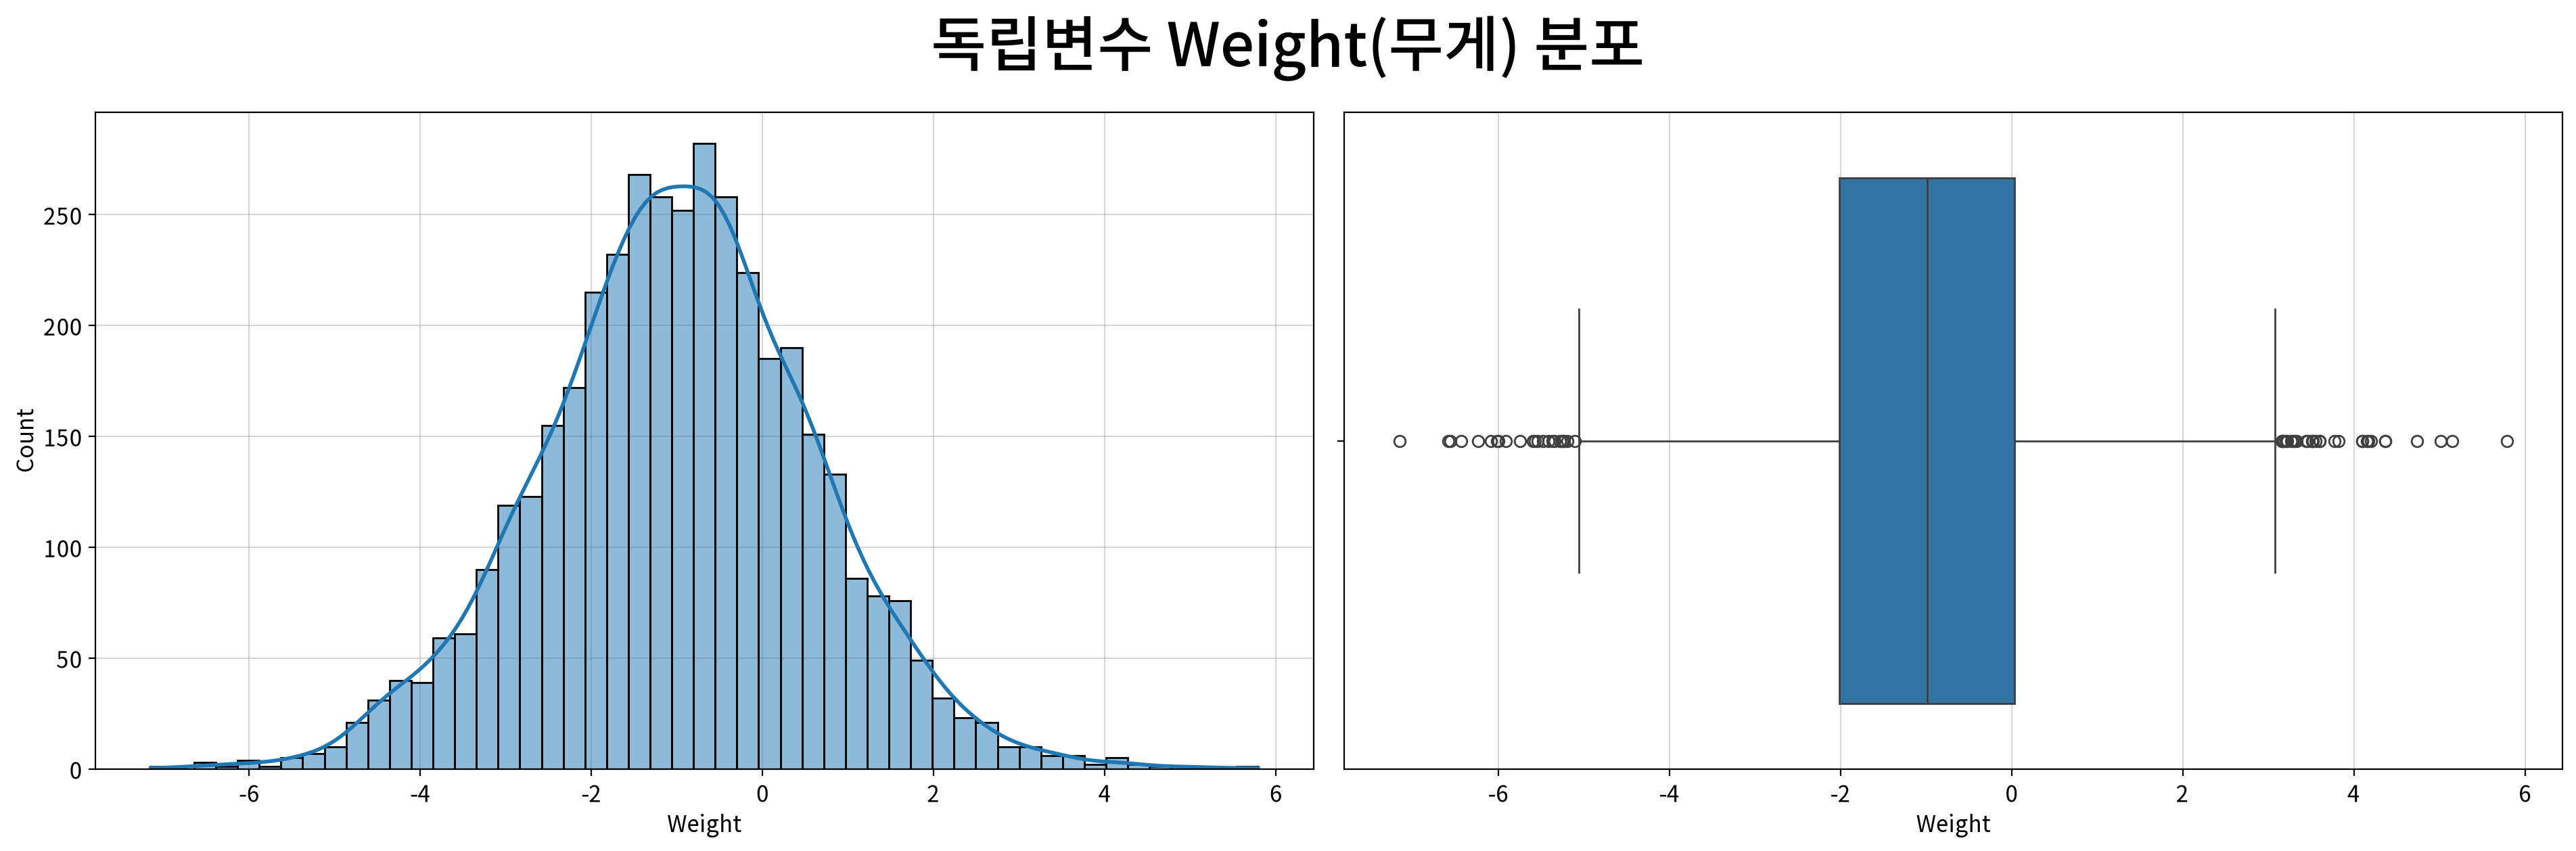

,Weight
count,4000.000
mean,-0.990
std,1.603
min,-7.150
25%,-2.012
50%,-0.985
75%,0.031
max,5.791
rel_diff,-0.005
rdiff_flag,similar


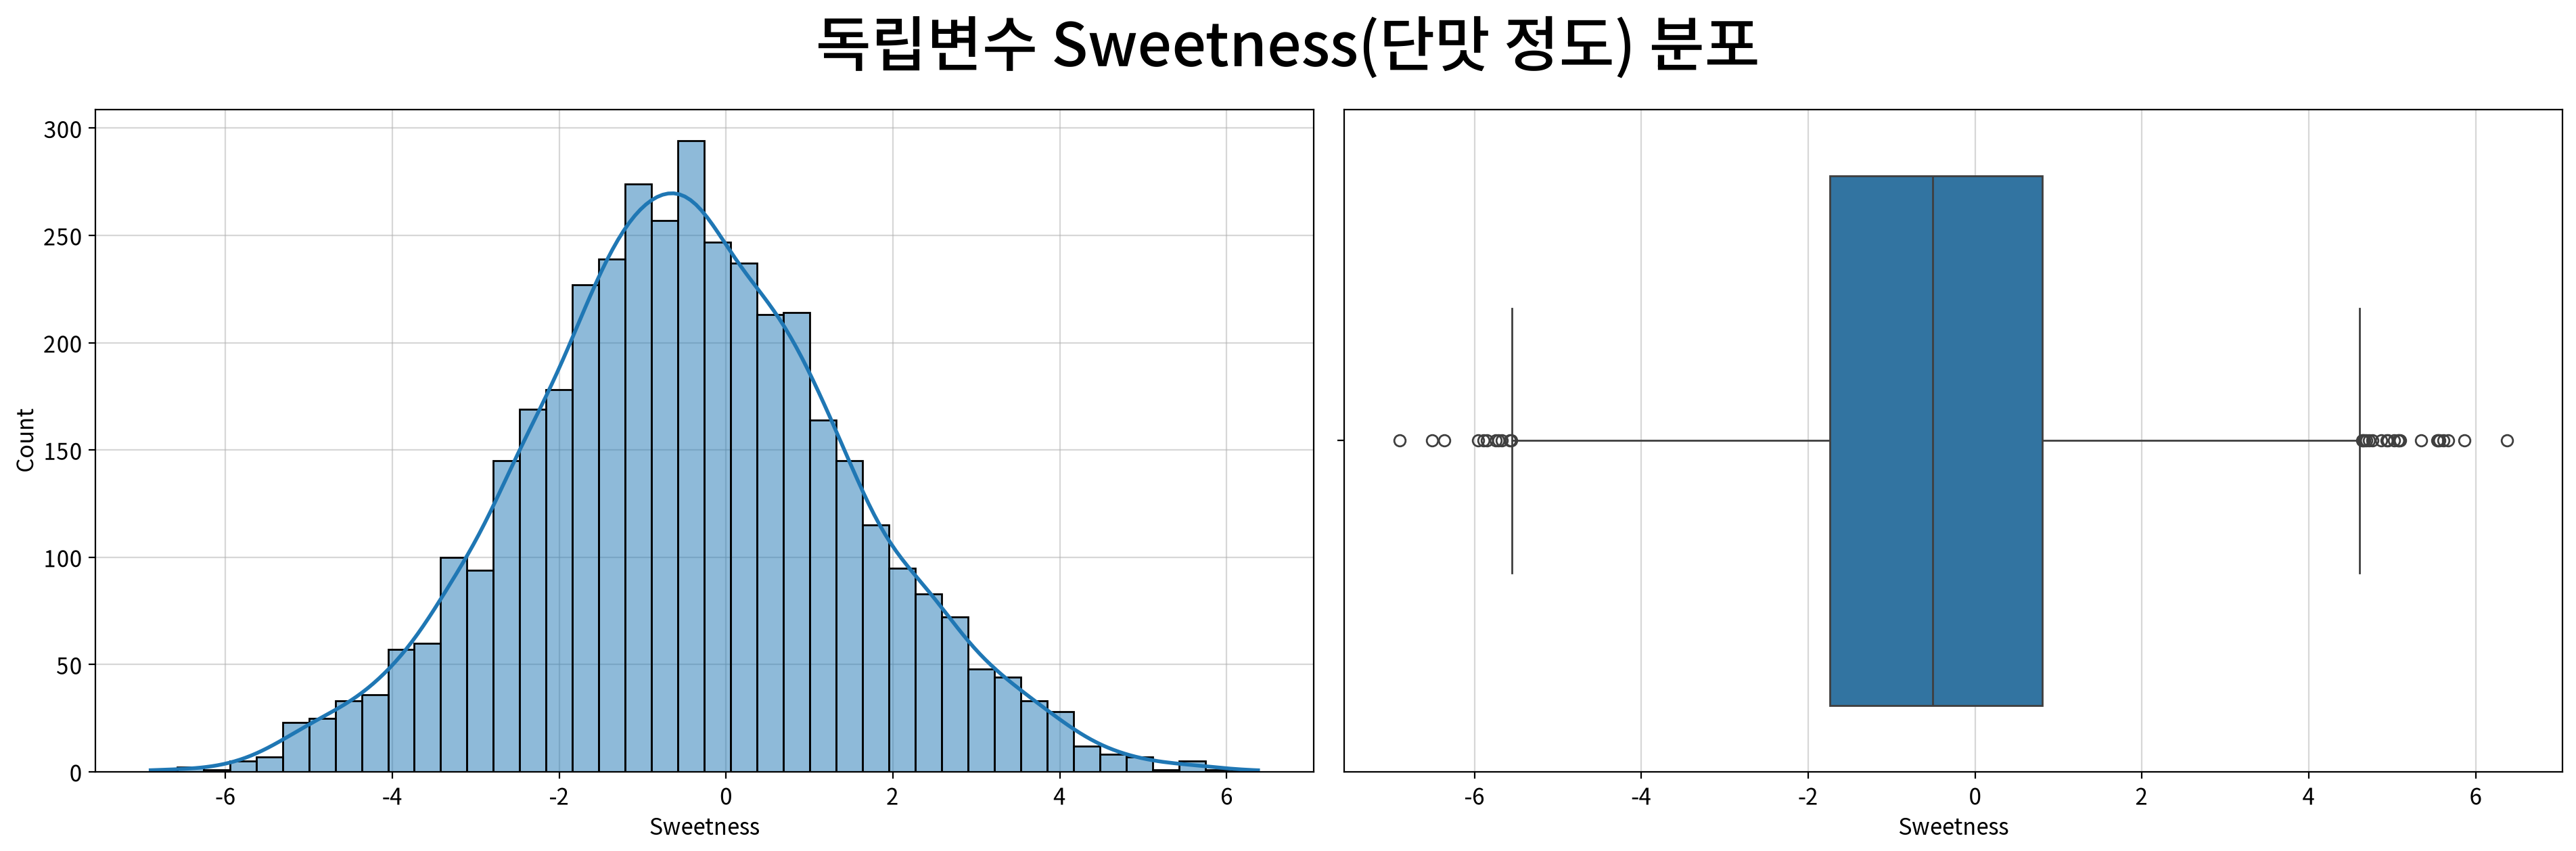

,Sweetness
count,4000.000
mean,-0.470
std,1.943
min,-6.894
25%,-1.738
50%,-0.505
75%,0.802
max,6.375
rel_diff,-0.068
rdiff_flag,similar


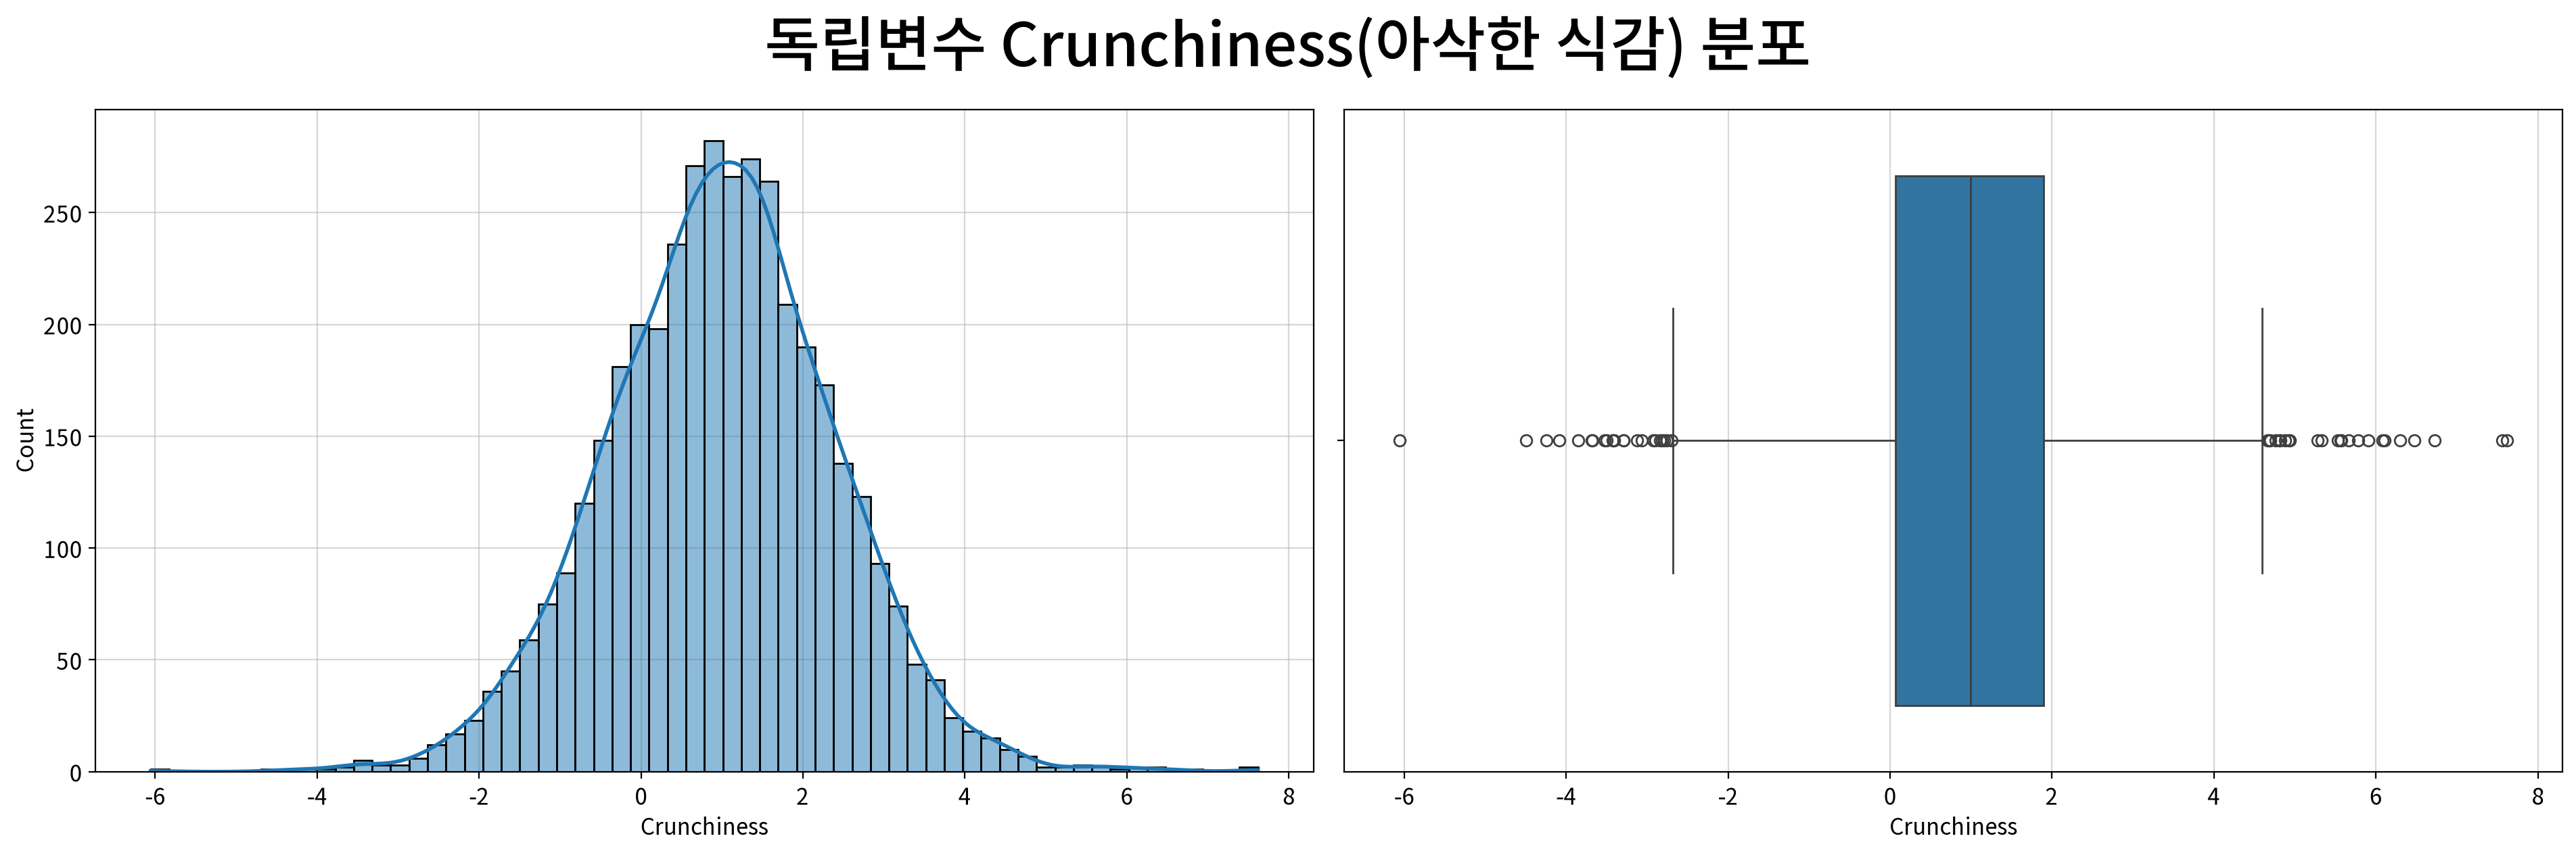

,Crunchiness
count,4000.000
mean,0.985
std,1.403
min,-6.055
25%,0.063
50%,0.998
75%,1.894
max,7.620
rel_diff,0.013
rdiff_flag,similar


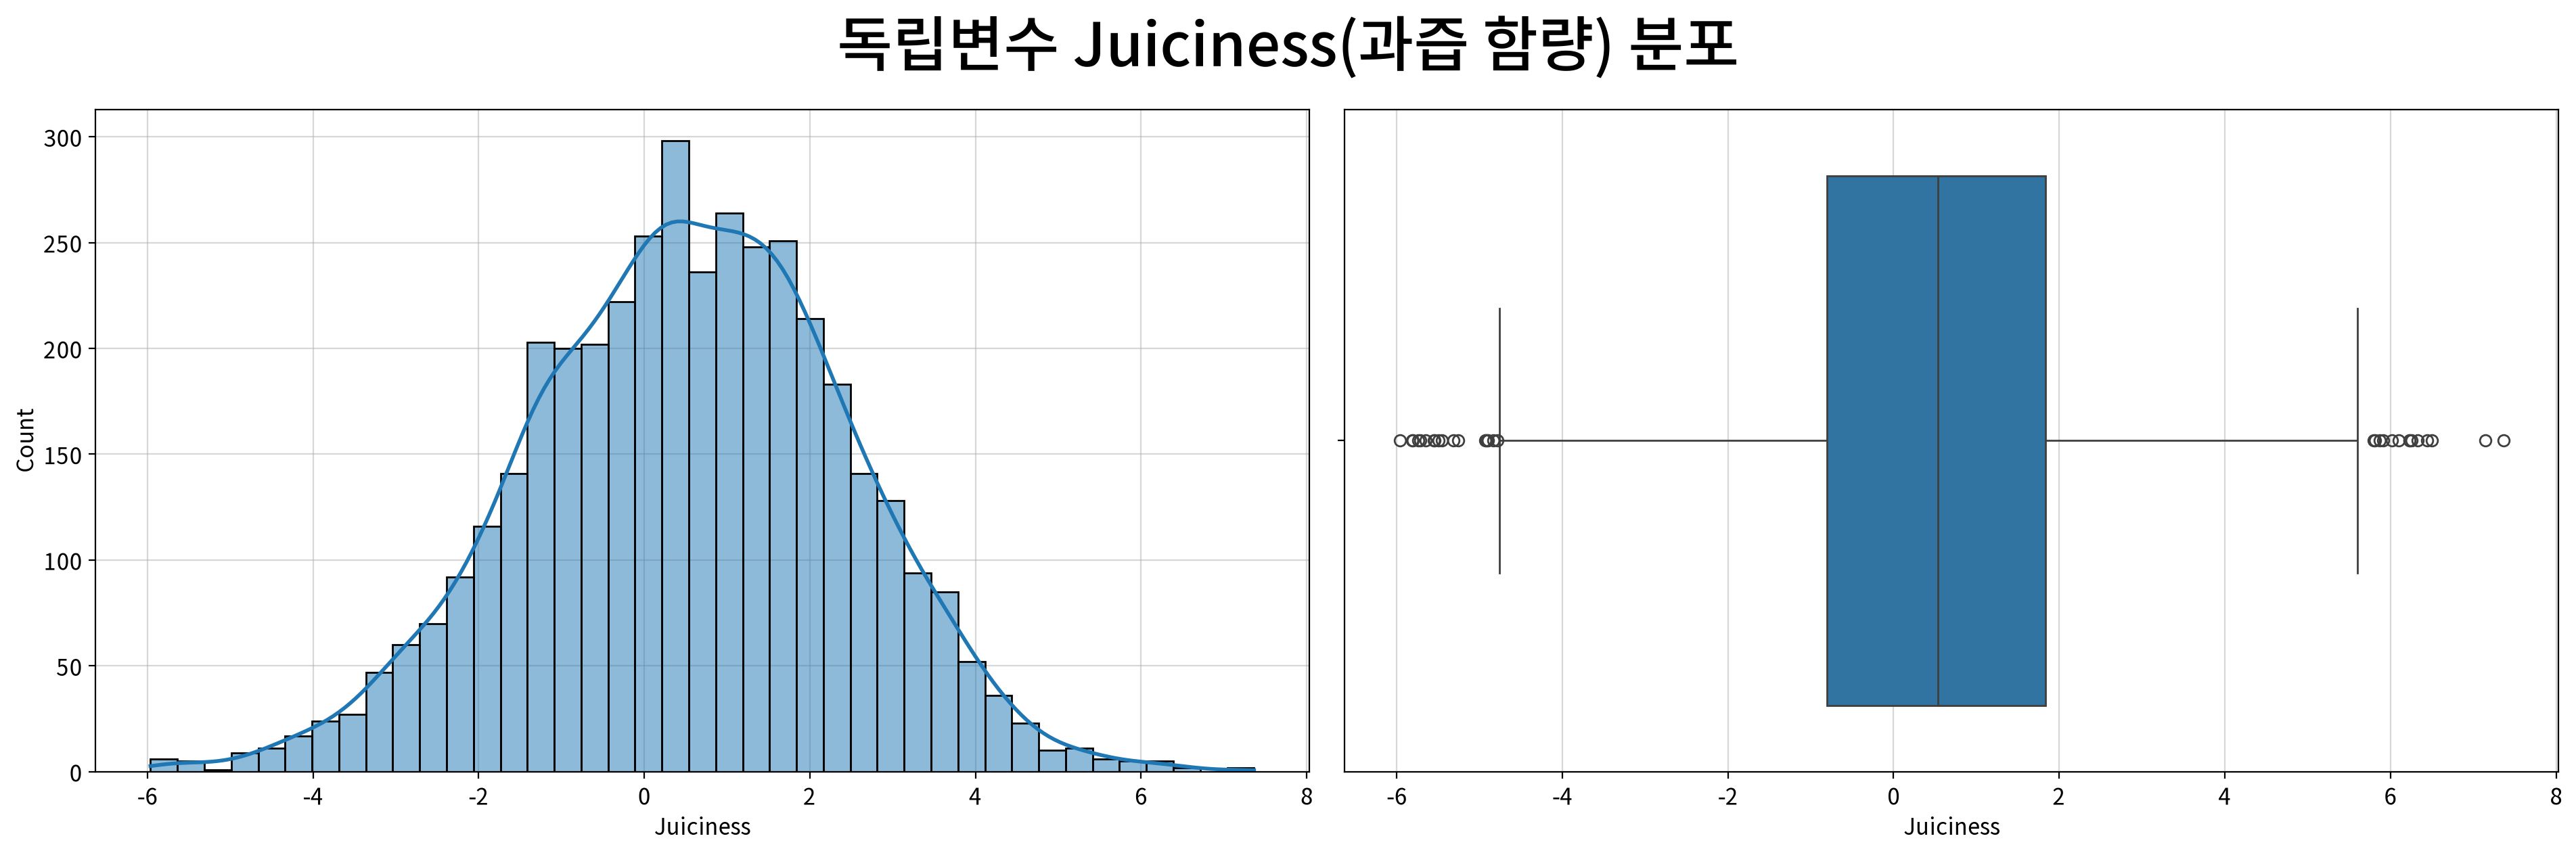

,Juiciness
count,4000.000
mean,0.512
std,1.930
min,-5.962
25%,-0.801
50%,0.534
75%,1.836
max,7.364
rel_diff,0.041
rdiff_flag,similar


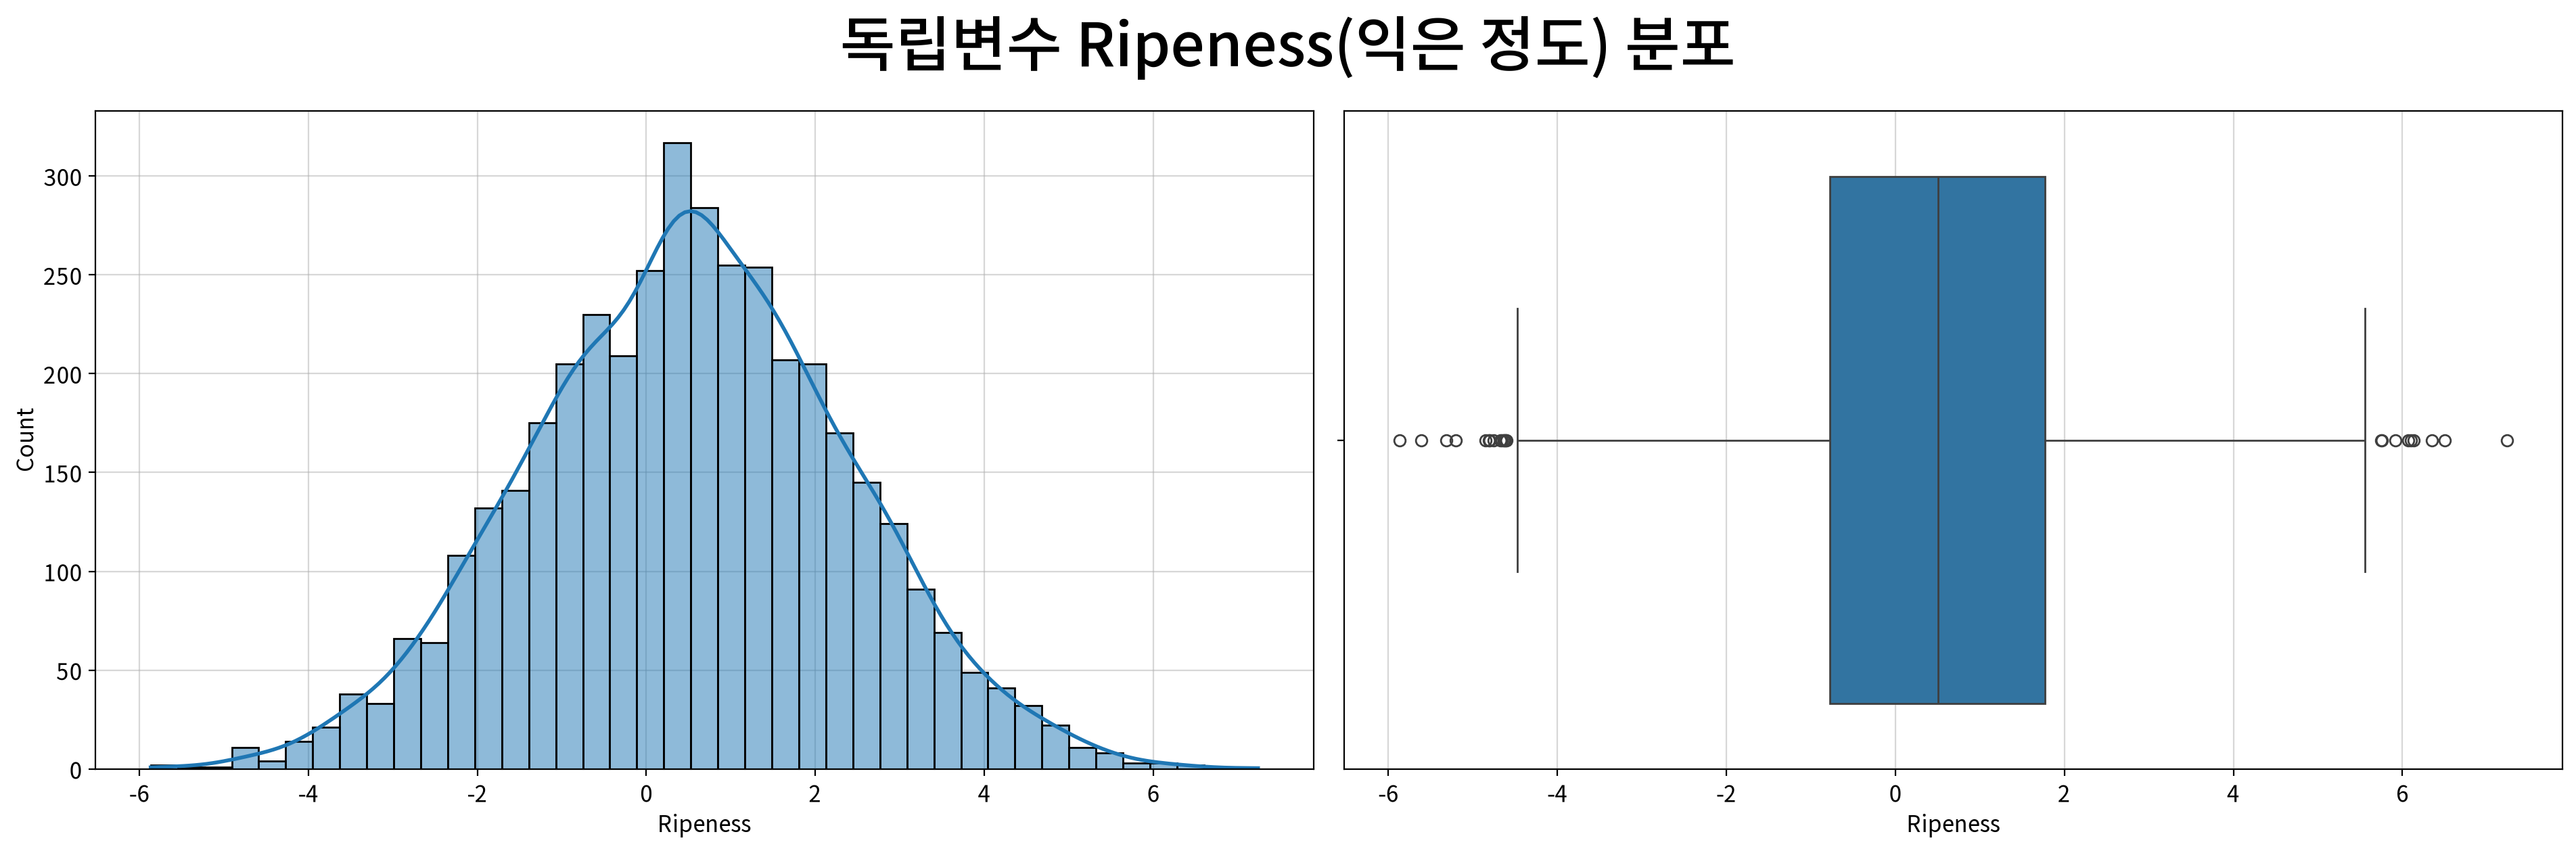

,Ripeness
count,4000.000
mean,0.498
std,1.874
min,-5.865
25%,-0.772
50%,0.503
75%,1.766
max,7.238
rel_diff,0.010
rdiff_flag,similar


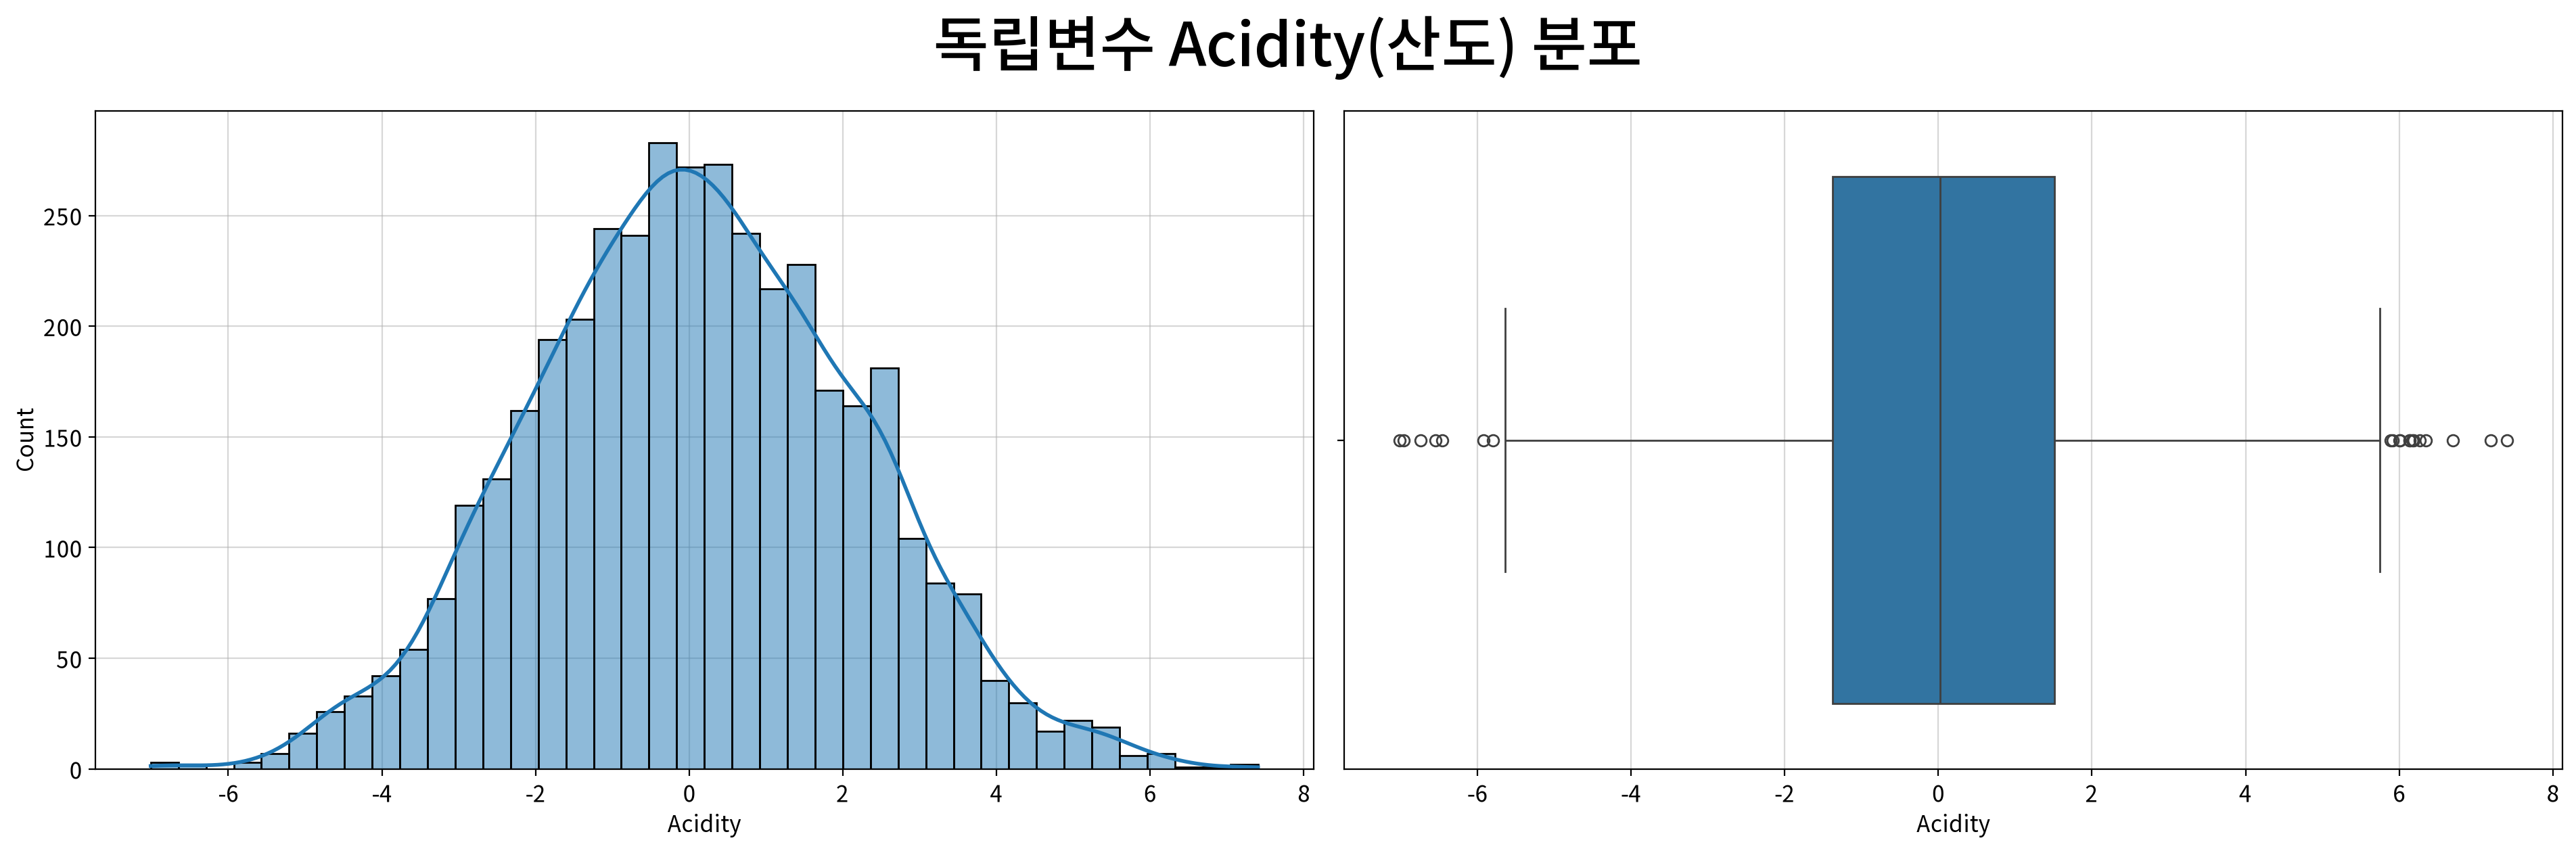

,Acidity
count,4000.000
mean,0.077
std,2.110
min,-7.011
25%,-1.377
50%,0.023
75%,1.510
max,7.405
rel_diff,2.400
rdiff_flag,large_diff


In [13]:
for f in continuous_cols:
    fig, ax = my_plot.init(rows=1, cols=2, width=960, height=640,
                title=f"독립변수 {f}({column_means[f]}) 분포")
    my_plot.histplot(data=df, x=f, kde=True, ax=ax[0])
    my_plot.boxplot(data=df, x=f, ax=ax[1])
    my_plot.show()

    display(num_desc[num_desc.index == f].T)

#### 💡 인사이트

| 변수 | 분포 모양(왜도) | 봉우리 수 | 이상치 | 판단·조치 |
|---|---|---|---|---|
| `Size` | 대칭 (−0.002) | 단봉 | 22건 (0.5%) | 변환 불필요 |
| `Weight` | 대칭 (+0.003) | 단봉 | 54건 (1.3%) | 변환 불필요 |
| `Sweetness` | 대칭 (+0.084) | 단봉 | 32건 (0.8%) | 변환 불필요 |
| `Crunchiness` | 대칭 (0.000) | 단봉 | 47건 (1.2%) | 변환 불필요 |
| `Juiciness` | 대칭 (−0.113) | 단봉 | 32건 (0.8%) | 변환 불필요 |
| `Ripeness` | 대칭 (−0.009) | 단봉 | 24건 (0.6%) | 변환 불필요 |
| `Acidity` | 대칭 (+0.056) | 단봉 | 20건 (0.5%) | 변환 불필요 |

## #05. 이변량 분석

### 1. T-Test (x: 연속형 독립변수 → y: 2집단 명목형 종속변수)

- 선형회귀에서 **상관분석**이 하던 역할("이 독립변수가 종속변수와 관련이 있는가")을
  로지스틱 회귀에서는 **T검정**이 맡는다.

#### ▶︎ Size(크기) → Quality

statistic  p-value  significant      result
test                alternative                                              
Mann-Whitney U test two-sided   1433524.000    0.000         True  bad ≠ good
                    less        1433524.000    0.000         True  bad < good
                    greater     1433524.000    1.000        False  bad ≤ good

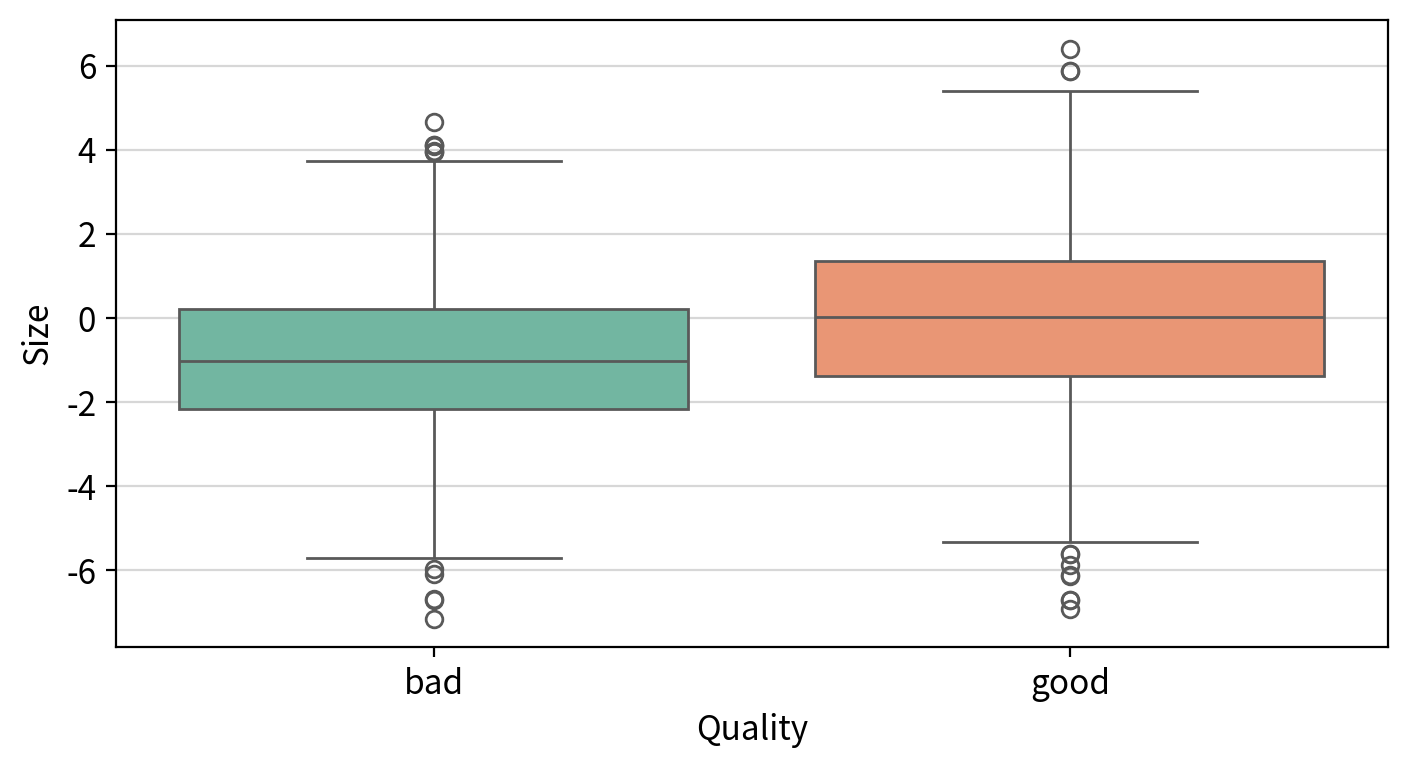

#### ▶︎ Weight(무게) → Quality

statistic  p-value  significant      result
test         alternative                                             
Welch t-test two-sided       -0.090    0.928        False  bad = good
             less            -0.090    0.464        False  bad ≥ good
             greater         -0.090    0.536        False  bad ≤ good

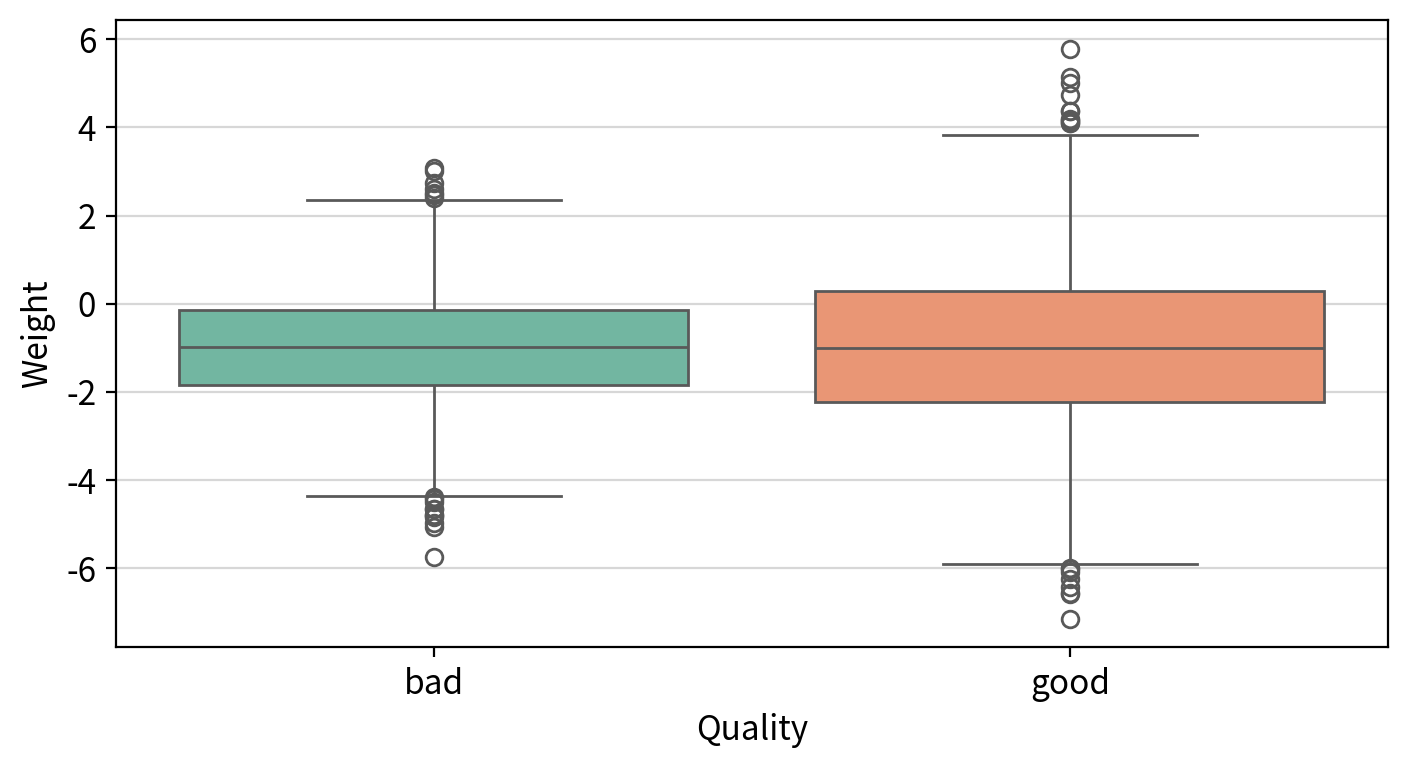

#### ▶︎ Sweetness(단맛 정도) → Quality

statistic  p-value  significant      result
test                alternative                                              
Mann-Whitney U test two-sided   1452149.000    0.000         True  bad ≠ good
                    less        1452149.000    0.000         True  bad < good
                    greater     1452149.000    1.000        False  bad ≤ good

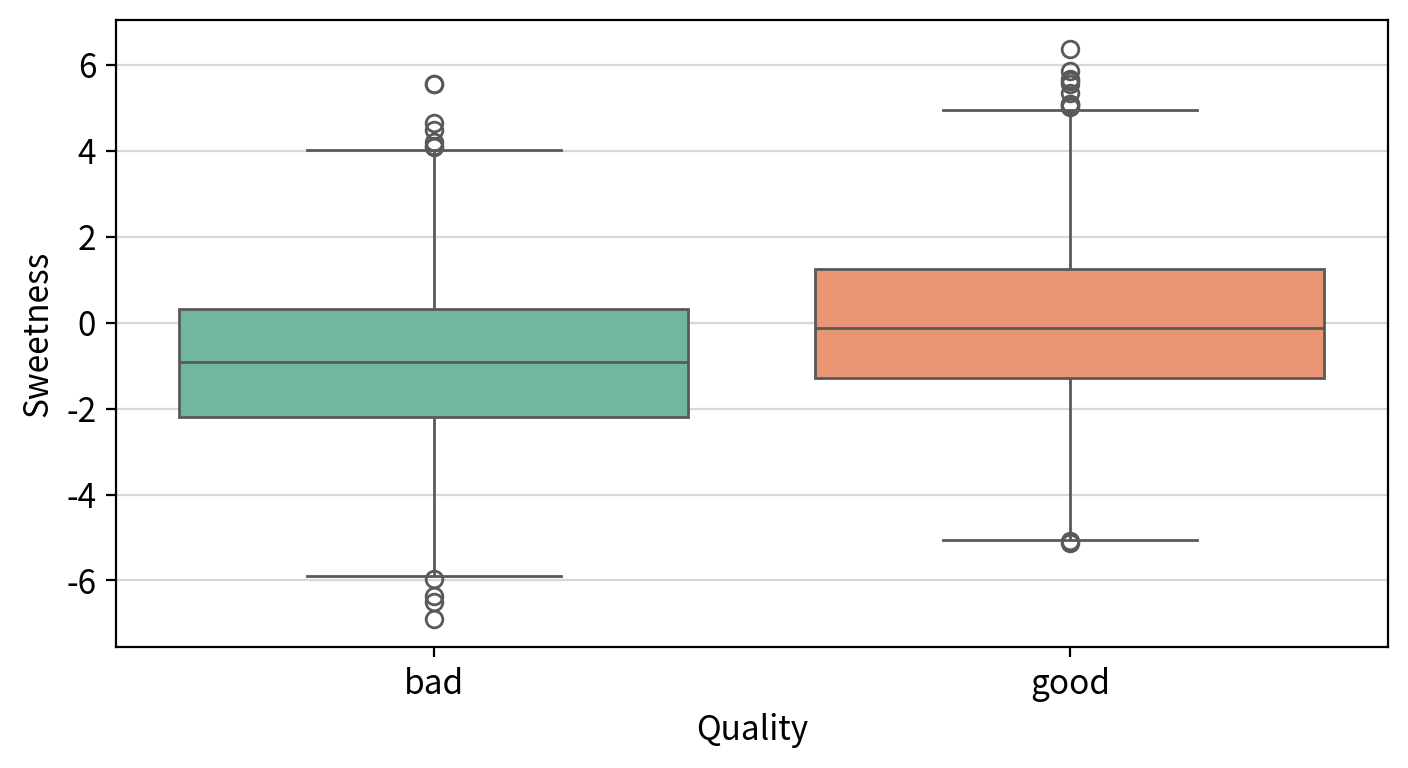

#### ▶︎ Crunchiness(아삭한 식감) → Quality

statistic  p-value  significant      result
test                alternative                                              
Mann-Whitney U test two-sided   1999316.000    0.985        False  bad = good
                    less        1999316.000    0.493        False  bad ≥ good
                    greater     1999316.000    0.507        False  bad ≤ good

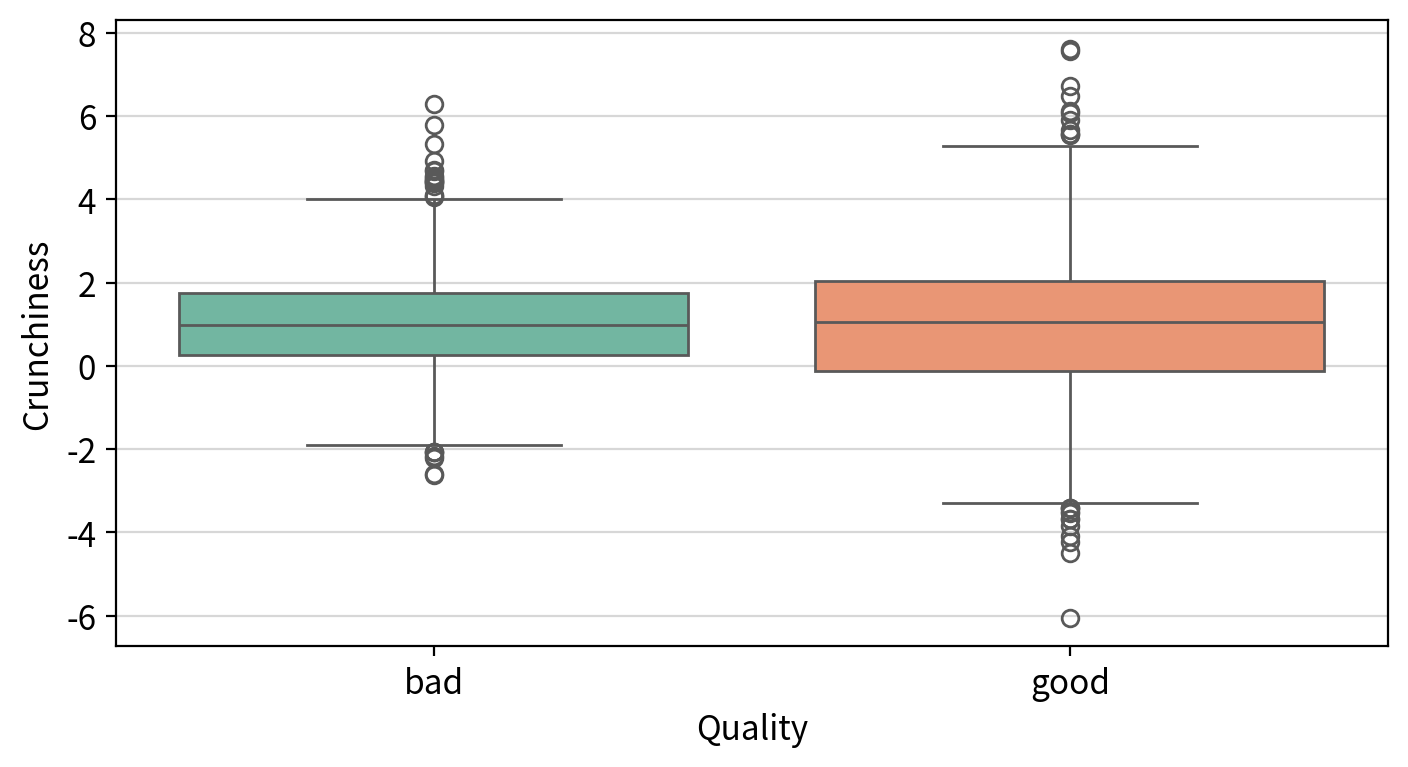

#### ▶︎ Juiciness(과즙 함량) → Quality

statistic  p-value  significant      result
test         alternative                                             
Welch t-test two-sided      -17.035    0.000         True  bad ≠ good
             less           -17.035    0.000         True  bad < good
             greater        -17.035    1.000        False  bad ≤ good

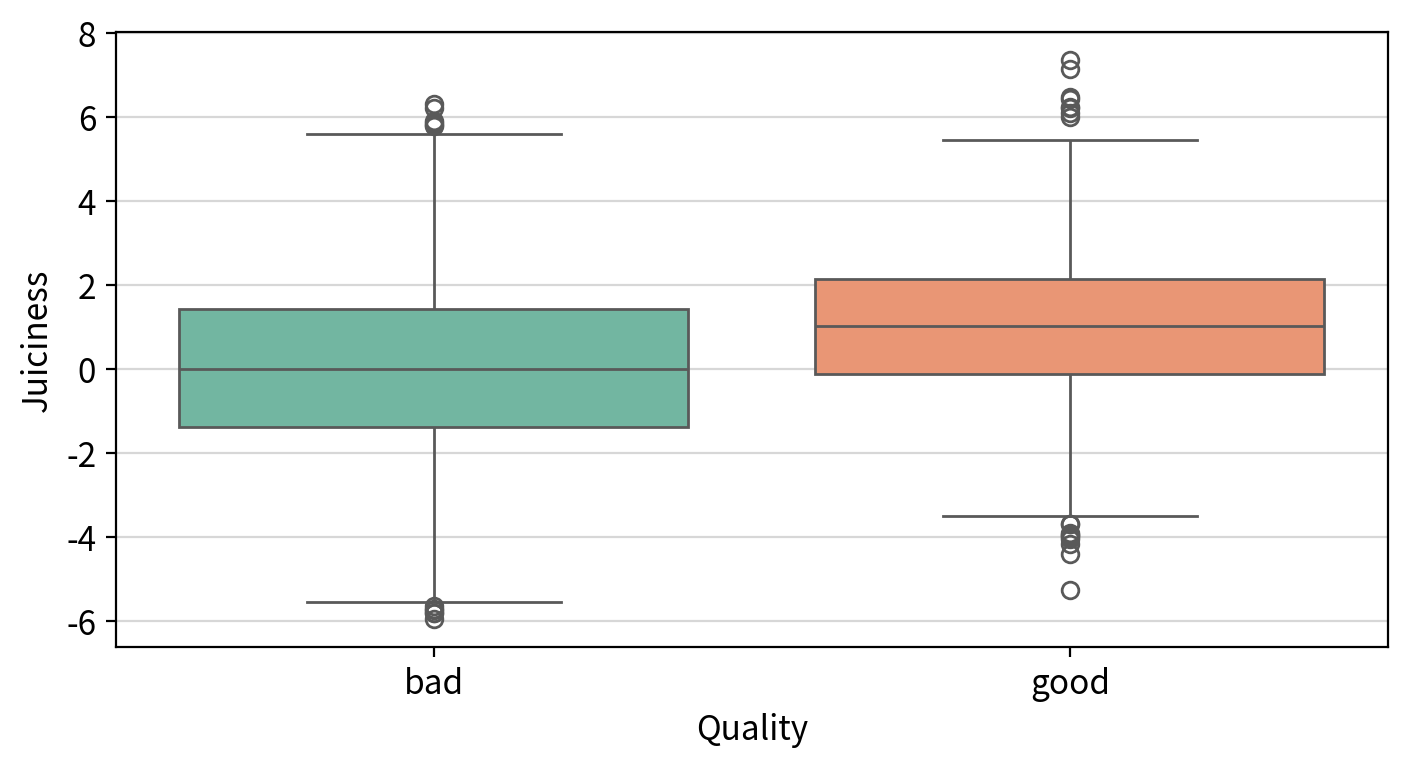

#### ▶︎ Ripeness(익은 정도) → Quality

statistic  p-value  significant      result
test         alternative                                             
Welch t-test two-sided       17.326    0.000         True  bad ≠ good
             less            17.326    1.000        False  bad ≥ good
             greater         17.326    0.000         True  bad > good

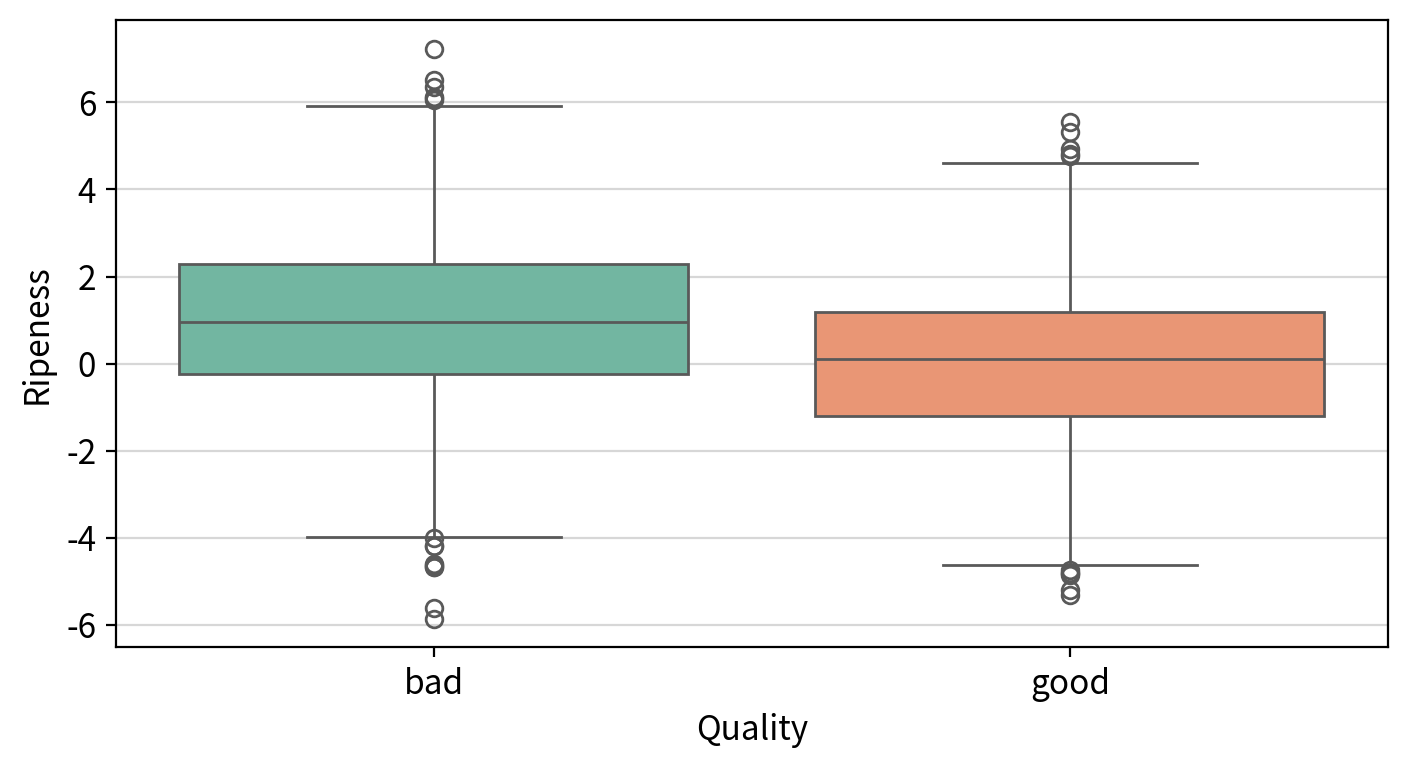

#### ▶︎ Acidity(산도) → Quality

statistic  p-value  significant      result
test                alternative                                              
Mann-Whitney U test two-sided   1990597.000    0.797        False  bad = good
                    less        1990597.000    0.399        False  bad ≥ good
                    greater     1990597.000    0.602        False  bad ≤ good

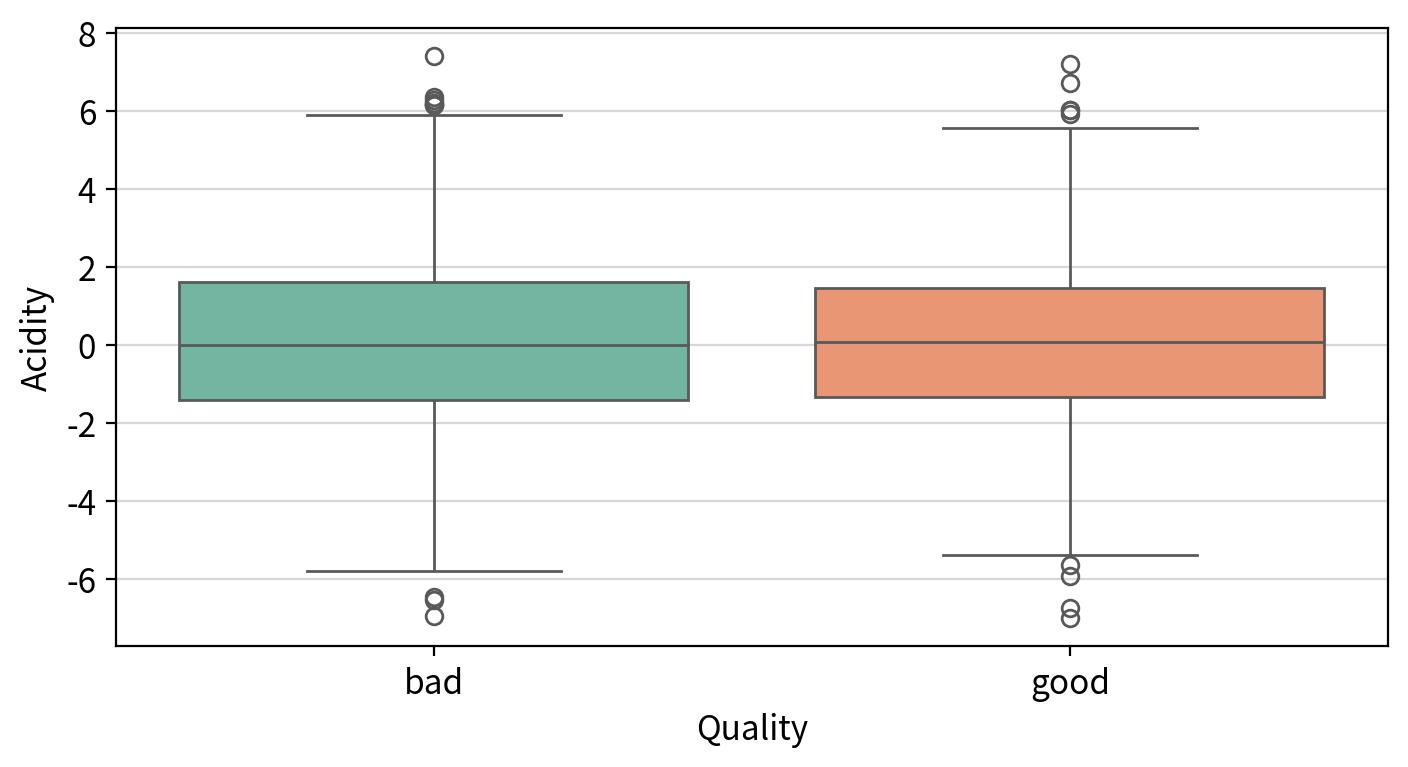

In [67]:
# 연속형 독립변수 이름을 탐색하면서 반복
for f in continuous_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {f}({column_means[f]}) → {target}"))

    # 수집된 데이터가 long 타입이므로 검정 대상만 wide 타입으로 변환해야 한다.
    # -> 선형회귀 때와 hue/values 가 서로 뒤바뀐다. (종속변수가 집단 기준이 되므로)
    wide_df = my_prep.long2wide(df, hue=target, values=f)
    display(my_stats.test_independent(wide_df,
                group1=wide_df.columns[0], group2=wide_df.columns[1], plot=False))

    # 시각화: 종속변수 집단별 분포 비교
    my_plot.boxplot(data=df, x=target, y=f, hue=target, palette="Set2",
                    width=720, height=400)

#### 💡 인사이트

| 변수 | 검정 방법 | 유의확률 | 집단 차이 | 방향 | 단독 채택 |
|---|---|---|---|---|---|
| `Size` | Mann-Whitney U | < 0.001 | 유의 | `bad` < `good` | ✅ |
| `Sweetness` | Mann-Whitney U | < 0.001 | 유의 | `bad` < `good` | ✅ |
| `Ripeness` | T검정 | < 0.001 | 유의 | `bad` > `good` | ✅ |
| `Juiciness` | T검정 | < 0.001 | 유의 | `bad` < `good` | ✅ |
| `Weight` | T검정 | 0.928 | **차이 없음** | — | 🟡 보류 |
| `Acidity` | Mann-Whitney U | 0.797 | **차이 없음** | — | 🟡 보류 |
| `Crunchiness` | Mann-Whitney U | 0.985 | **차이 없음** | — | 🟡 보류 |

### 2. 교차분석 (x: 명목형 독립변수 → y: 명목형 종속변수)

- 명목형 독립변수가 있을 경우 카이제곱 독립성 검정을 수행한다.
  - 명목형 독립변수가 없을 경우 출력 결과가 없을 수 있다.

In [15]:
for n in nominal_cols:
    # 빈 줄 출력용
    print()

    # 분석 단위 제목 출력
    display(Markdown(f"#### ▶︎ {n}({column_means[n]}) → {target}"))

    # 교차분석 (카이제곱 독립성 검정)
    display(my_stats.chi2_independence(df, x=n, y=target, plot=False))

#### 💡 인사이트

> 이 데이터셋에는 **명목형 독립변수가 없으므로** 해당 없음. (출력 결과 없음)

## #06. 다변량 분석

### 1. 독립변수간 상관 분석

- 연속형 독립변수끼리는 종속변수가 명목형이어도 상관분석을 그대로 쓸 수 있다.
- 목적이 다르다. 여기서는 **설명력 확인이 아니라 다중공선성 점검**이다.

In [16]:
corr = my_stats.multi_correlation(df, columns=continuous_cols, plot=False)
my_stats.correlation_summary(corr)

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
Size,1.000,-0.144,-0.325,0.172,-0.032,-0.155,0.210
Weight,-0.144,1.000,-0.120,-0.087,-0.091,-0.244,0.030
Sweetness,-0.325,-0.120,1.000,-0.017,0.098,-0.255,0.072
Crunchiness,0.172,-0.087,-0.017,1.000,-0.236,-0.184,0.074
Juiciness,-0.032,-0.091,0.098,-0.236,1.000,-0.124,0.231
Ripeness,-0.155,-0.244,-0.255,-0.184,-0.124,1.000,-0.195
Acidity,0.210,0.030,0.072,0.074,0.231,-0.195,1.000


,max-y,max-coef,count,columns
x,,,,
Size,Sweetness,-0.325,0,-
Sweetness,Size,-0.325,0,-
Ripeness,Sweetness,-0.255,0,-
Weight,Ripeness,-0.244,0,-
Crunchiness,Juiciness,-0.236,0,-
Juiciness,Crunchiness,-0.236,0,-
Acidity,Juiciness,0.231,0,-


#### 💡 인사이트

- `correlation_summary()`에서 **Strong(|r| ≥ 0.7) 조합이 하나도 나오지 않았다.**
- → **다중공선성 문제 없음.** 7개 변수를 모두 투입해도 계수가 불안정해지지 않는다.

## #07. 최종 변수 선택

| 채택여부 | 변수 | 검정방법 | 유의확률 | 방향 | 공선성 신호 | 근거 |
|---|---|---|---|---|---|---|
| ✅ 채택 | `Size` | Mann-Whitney U | < 0.001 | `bad` < `good` | X (VIF 1.41) | 집단 차이 유의 |
| ✅ 채택 | `Sweetness` | Mann-Whitney U | < 0.001 | `bad` < `good` | X (VIF 1.48) | 집단 차이 유의 |
| ✅ 채택 | `Juiciness` | T검정 | < 0.001 | `bad` < `good` | X (VIF 1.22) | 집단 차이 유의 |
| ✅ 채택 | `Ripeness` | T검정 | < 0.001 | `bad` > `good` | X (VIF 1.48) | 집단 차이 유의 (유일한 음의 방향) |
| 🟡 보류 | `Weight` | T검정 | 0.928 | — | X (VIF 1.35) | 단독 차이는 없으나 **억제효과 가능성** → 투입 후 계수로 판정 |
| 🟡 보류 | `Acidity` | Mann-Whitney U | 0.797 | — | X (VIF 1.17) | 단독 차이는 없으나 **억제효과 가능성** → 투입 후 계수로 판정 |
| 🟡 보류 | `Crunchiness` | Mann-Whitney U | 0.985 | — | X (VIF 1.22) | 단독 차이는 없으나 **억제효과 가능성** → 투입 후 계수로 판정 |
| ❌ 제외 | `A_id` | — | — | — | — | 행마다 값이 다른 **식별자** (#02에서 제거) |

- **제외는 `A_id` 하나뿐**이다. 나머지 7종은 전부 모델에 투입한 뒤 **후진소거법으로 판정**한다.
- 이유: 공선성이 없어 변수를 다 넣어도 부작용이 없고, T검정에서 탈락한 3종은 **다른 변수를 통제했을 때 살아날 수 있기 때문**이다.